# Feature Engineering for Subrogation Prediction

This notebook implements a structured and reproducible feature engineering pipeline for predicting insurance claim subrogation.

The objective is to transform raw claims data into a clean, interpretable, and model-ready feature set while:
- Avoiding data leakage
- Preserving interpretability
- Capturing behavioral, temporal, and monetary risk signals

All engineered features are derived exclusively from information available at claim creation time.


In [1]:
# Imports
import pandas as pd
import numpy as np

In [2]:
# Work on a copy to preserve raw data
df_subrogation = pd.read_csv('/Users/eugene/Desktop/Emory/Projects/Travelers/data/raw/Training_TriGuard.csv')
df = df_subrogation.copy()
df.head()

,subrogation,claim_number,year_of_born,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,...,claim_est_payout,vehicle_made_year,vehicle_category,vehicle_price,vehicle_color,vehicle_weight,age_of_DL,accident_type,in_network_bodyshop,vehicle_mileage
0,1.0,6090851,1990.0,F,0.0,75.0,70966.0,1.0,1.0,Rent,...,3218.84,2021.0,Large,16272.12725,red,21620.79697,25.0,multi_vehicle_clear,no,75421.0
1,0.0,4653734,1972.0,F,1.0,94.0,79723.0,1.0,1.0,Rent,...,1338.52,2025.0,Medium,34102.78197,silver,10840.58520,23.0,multi_vehicle_clear,yes,31988.0
2,0.0,1014777,2003.0,F,1.0,76.0,41527.0,1.0,1.0,Own,...,3540.05,2022.0,Compact,15000.00000,silver,24318.12282,23.0,multi_vehicle_unclear,yes,60876.0
3,1.0,8101873,1983.0,F,1.0,54.0,42099.0,1.0,1.0,Rent,...,1507.94,2025.0,Medium,16984.45295,white,36958.26656,23.0,multi_vehicle_unclear,yes,152772.0
4,0.0,5081870,1985.0,F,1.0,54.0,47206.0,1.0,1.0,Own,...,5080.63,2021.0,Compact,46545.72863,blue,11779.17422,17.0,multi_vehicle_clear,yes,41151.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18001 entries, 0 to 18000
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subrogation              17999 non-null  float64
 1   claim_number             18001 non-null  int64  
 2   year_of_born             18000 non-null  float64
 3   gender                   18000 non-null  object 
 4   email_or_tel_available   18000 non-null  float64
 5   safety_rating            18000 non-null  float64
 6   annual_income            18000 non-null  float64
 7   high_education_ind       18000 non-null  float64
 8   address_change_ind       18000 non-null  float64
 9   living_status            18000 non-null  object 
 10  zip_code                 18000 non-null  float64
 11  claim_date               18000 non-null  object 
 12  claim_day_of_week        18000 non-null  object 
 13  accident_site            18000 non-null  object 
 14  past_num_of_claims    

In [4]:
df.isna().sum().sort_values(ascending=False).head()

subrogation            2
witness_present_ind    1
in_network_bodyshop    1
accident_type          1
age_of_DL              1
dtype: int64

In [5]:
df = df.dropna(subset=["subrogation"])
df.isna().sum().sort_values(ascending=False).head()

subrogation            0
witness_present_ind    0
in_network_bodyshop    0
accident_type          0
age_of_DL              0
dtype: int64

In [6]:
df["subrogation"] = df["subrogation"].astype(int)

## Feature Engineering Strategy

Features are engineered following these principles:

1. Temporal consistency (no post-outcome data)
2. Interpretability for business stakeholders
3. Robust handling of outliers and missing data
4. Compatibility with statistical and ML models

Feature groups:
- Temporal features
- Demographic features
- Monetary & severity features
- Behavioral / historical features
- Binary indicators
- Categorical variables (identified here, encoded later)


## Temporal Feature Construction

Temporal features capture seasonality, reporting patterns, and macro-level trends that may influence subrogation likelihood.


In [7]:
# Date decomposition
df["claim_date"] = pd.to_datetime(df["claim_date"])
df["claim_year"] = df["claim_date"].dt.year
df["claim_month"] = df["claim_date"].dt.month
df["claim_quarter"] = df["claim_month"].sub(1).floordiv(3) + 1
df["is_holiday_season"] = df["claim_month"].isin([11, 12]).astype(int)


## Demographic Feature Engineering

Driver characteristics are transformed into interpretable risk-related features.


In [8]:
# Driver age construction
df["driver_age"] = df["claim_year"] - df["year_of_born"]
df.loc[
    (df["driver_age"] < 16) | (df["driver_age"] > 100),
    "driver_age"
] = np.nan


## Monetary and Severity Features

Insurance claim costs are typically right-skewed and require transformation for stable modeling.


In [9]:
# Log-Transformation of monetary variables
df["log_claim_est_payout"] = np.log1p(df["claim_est_payout"])
df["log_vehicle_price"] = np.log1p(df["vehicle_price"])


In [10]:
# Relative severity feature
df["payout_to_vehicle_value_ratio"] = (
    df["claim_est_payout"] / df["vehicle_price"]
)


In [11]:
df.head()

,subrogation,claim_number,year_of_born,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,...,in_network_bodyshop,vehicle_mileage,claim_year,claim_month,claim_quarter,is_holiday_season,driver_age,log_claim_est_payout,log_vehicle_price,payout_to_vehicle_value_ratio
0,1,6090851,1990.0,F,0.0,75.0,70966.0,1.0,1.0,Rent,...,no,75421.0,2016,12,4,1,26.0,8.077087,9.697270,0.197813
1,0,4653734,1972.0,F,1.0,94.0,79723.0,1.0,1.0,Rent,...,yes,31988.0,2015,4,2,0,43.0,7.200067,10.437164,0.039250
2,0,1014777,2003.0,F,1.0,76.0,41527.0,1.0,1.0,Own,...,yes,60876.0,2015,6,2,0,NaN,8.172179,9.615872,0.236003
3,1,8101873,1983.0,F,1.0,54.0,42099.0,1.0,1.0,Rent,...,yes,152772.0,2015,3,1,0,32.0,7.319163,9.740113,0.088784
4,0,5081870,1985.0,F,1.0,54.0,47206.0,1.0,1.0,Own,...,yes,41151.0,2016,1,1,0,31.0,8.533387,10.748212,0.109154


In [12]:
# Analyzing predictive streongth of payout_to_vehicle_value_ratio
print(min(df.payout_to_vehicle_value_ratio))
print(max(df.payout_to_vehicle_value_ratio))

0.0013283689267968232
1.4336186666666666


                 mean    median
subrogation                    
0            0.165343  0.099767
1            0.158601  0.096345


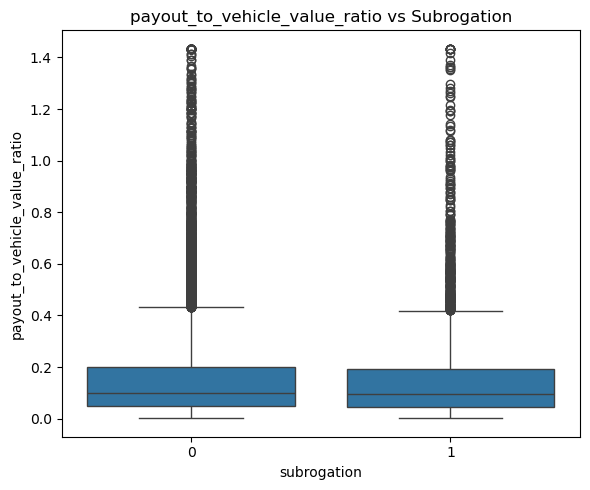

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
stats = (df.groupby("subrogation")['payout_to_vehicle_value_ratio']
         .describe()[["mean", "50%"]]
         .rename(columns={"50%": "median"}))
print(stats)

plt.figure(figsize=(6, 5))
sns.boxplot(x="subrogation", y='payout_to_vehicle_value_ratio', data=df)
plt.title(f"{'payout_to_vehicle_value_ratio'} vs Subrogation")
plt.tight_layout()
plt.show()

In [14]:
df["high_severity_ind"] = (df["payout_to_vehicle_value_ratio"] > 1.0).astype(int)

pd.crosstab(
    df["high_severity_ind"],
    df["subrogation"],
    normalize="index"
)


subrogation,0,1
high_severity_ind,,
0,0.771329,0.228671
1,0.775956,0.224044


In [15]:
# Drop after EDA shows no predictive value
df.drop(columns=["payout_to_vehicle_value_ratio", "high_severity_ind"], inplace=True)

**Observation:**

Although the payout-to-vehicle-value ratio captures relative claim severity, exploratory analysis shows substantial overlap across subrogation outcomes and no increase in subrogation rates for extreme values. Given the absence of liability and recoverability indicators, this feature was excluded from the final modeling dataset.

In [16]:
df.head()

,subrogation,claim_number,year_of_born,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,...,accident_type,in_network_bodyshop,vehicle_mileage,claim_year,claim_month,claim_quarter,is_holiday_season,driver_age,log_claim_est_payout,log_vehicle_price
0,1,6090851,1990.0,F,0.0,75.0,70966.0,1.0,1.0,Rent,...,multi_vehicle_clear,no,75421.0,2016,12,4,1,26.0,8.077087,9.697270
1,0,4653734,1972.0,F,1.0,94.0,79723.0,1.0,1.0,Rent,...,multi_vehicle_clear,yes,31988.0,2015,4,2,0,43.0,7.200067,10.437164
2,0,1014777,2003.0,F,1.0,76.0,41527.0,1.0,1.0,Own,...,multi_vehicle_unclear,yes,60876.0,2015,6,2,0,NaN,8.172179,9.615872
3,1,8101873,1983.0,F,1.0,54.0,42099.0,1.0,1.0,Rent,...,multi_vehicle_unclear,yes,152772.0,2015,3,1,0,32.0,7.319163,9.740113
4,0,5081870,1985.0,F,1.0,54.0,47206.0,1.0,1.0,Own,...,multi_vehicle_clear,yes,41151.0,2016,1,1,0,31.0,8.533387,10.748212


                  mean  median
subrogation                   
0            35.523617    35.0
1            35.335853    34.0


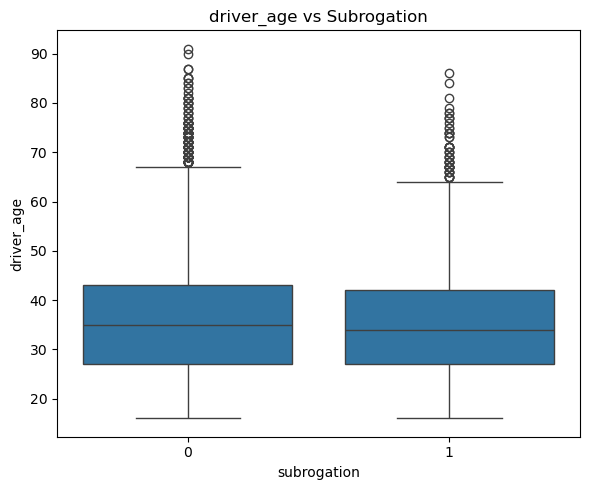

In [17]:
stats = (df.groupby("subrogation")['driver_age']
         .describe()[["mean", "50%"]]
         .rename(columns={"50%": "median"}))
print(stats)

plt.figure(figsize=(6, 5))
sns.boxplot(x="subrogation", y='driver_age', data=df)
plt.title(f"{'driver_age'} vs Subrogation")
plt.tight_layout()
plt.show()

In [18]:
df["driver_age_bin"] = pd.cut(
    df["driver_age"],
    bins=[16, 25, 35, 50, 65, 100],
    labels=["16–25", "26–35", "36–50", "51–65", "65+"]
)

pd.crosstab(
    df["driver_age_bin"],
    df["subrogation"],
    normalize="index"
)


subrogation,0,1
driver_age_bin,,
16–25,0.760304,0.239696
26–35,0.774113,0.225887
36–50,0.774454,0.225546
51–65,0.769529,0.230471
65+,0.782805,0.217195


In [19]:
# Drop after EDA shows no predictive value
df.drop(columns=["driver_age", "driver_age_bin", "claim_year", "year_of_born"], inplace=True)

In [20]:
df.head()

,subrogation,claim_number,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,zip_code,...,vehicle_weight,age_of_DL,accident_type,in_network_bodyshop,vehicle_mileage,claim_month,claim_quarter,is_holiday_season,log_claim_est_payout,log_vehicle_price
0,1,6090851,F,0.0,75.0,70966.0,1.0,1.0,Rent,80040.0,...,21620.79697,25.0,multi_vehicle_clear,no,75421.0,12,4,1,8.077087,9.697270
1,0,4653734,F,1.0,94.0,79723.0,1.0,1.0,Rent,80030.0,...,10840.58520,23.0,multi_vehicle_clear,yes,31988.0,4,2,0,7.200067,10.437164
2,0,1014777,F,1.0,76.0,41527.0,1.0,1.0,Own,50012.0,...,24318.12282,23.0,multi_vehicle_unclear,yes,60876.0,6,2,0,8.172179,9.615872
3,1,8101873,F,1.0,54.0,42099.0,1.0,1.0,Rent,20138.0,...,36958.26656,23.0,multi_vehicle_unclear,yes,152772.0,3,1,0,7.319163,9.740113
4,0,5081870,F,1.0,54.0,47206.0,1.0,1.0,Own,50033.0,...,11779.17422,17.0,multi_vehicle_clear,yes,41151.0,1,1,0,8.533387,10.748212


**Observation:**

Driver age was derived from claim year and year of birth to create an interpretable, risk-relevant feature. The variable was evaluated in both continuous and binned forms to assess potential non-linear effects; however, subrogation rates remained stable across all age groups, indicating no meaningful predictive contribution. As a result, driver age was excluded from the final feature set. Consequently, the source variables (claim year and year of birth) were also removed to prevent redundancy, multicollinearity, and potential temporal leakage.

                  mean  median
subrogation                   
0            22.063959    22.0
1            22.008748    22.0


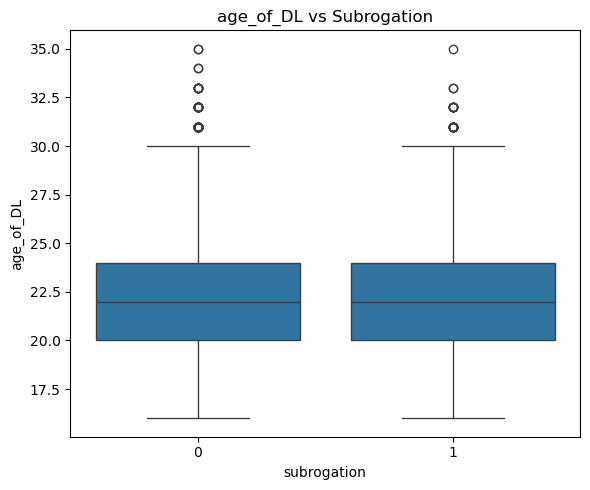

In [21]:
stats = (df.groupby("subrogation")['age_of_DL']
         .describe()[["mean", "50%"]]
         .rename(columns={"50%": "median"}))
print(stats)

plt.figure(figsize=(6, 5))
sns.boxplot(x="subrogation", y='age_of_DL', data=df)
plt.title(f"{'age_of_DL'} vs Subrogation")
plt.tight_layout()
plt.show()

In [22]:
df["age_of_DL_bin"] = pd.cut(
    df["age_of_DL"],
    bins=[15, 20, 25, 30, 35],
    labels=["16–20", "21–25", "26–30", "31–35"]
)

pd.crosstab(
    df["age_of_DL_bin"],
    df["subrogation"],
    normalize="index"
)



subrogation,0,1
age_of_DL_bin,,
16–20,0.766866,0.233134
21–25,0.773131,0.226869
26–30,0.776163,0.223837
31–35,0.754237,0.245763


In [23]:
print(min(df.age_of_DL))
print(max(df.age_of_DL))

16.0
35.0


In [24]:
# Drop after EDA shows no predictive value
df.drop(columns=["age_of_DL", "age_of_DL_bin"], inplace=True)

**Observation:**

Age of driver’s license was evaluated as a proxy for driving experience using continuous, visual, and binned analyses aligned with the observed data range. Subrogation rates remained stable across all experience levels, with no meaningful linear or non-linear patterns identified. The feature was therefore excluded from the final model due to lack of predictive contribution.

## Behavioral and Historical Features

Prior claim behavior often signals elevated future risk.


In [25]:
# Prior claims binning
df["past_claims_bin"] = pd.cut(
    df["past_num_of_claims"],
    bins=[-1, 0, 2, np.inf],
    labels=["none", "moderate", "frequent"]
)

In [26]:
# Prior claims indicator
df["has_prior_claims_ind"] = (df["past_num_of_claims"] > 0).astype(int)

In [27]:
df["past_claims_bin"].value_counts(dropna=False)

past_claims_bin
none        9875
frequent    6750
moderate    1374
Name: count, dtype: int64

In [28]:
df["has_prior_claims_ind"].value_counts(dropna=False)

has_prior_claims_ind
0    9875
1    8124
Name: count, dtype: int64

In [29]:
pd.crosstab(
    df["has_prior_claims_ind"],
    df["subrogation"],
    normalize="index"
)

subrogation,0,1
has_prior_claims_ind,,
0,0.77357,0.22643
1,0.76871,0.23129


In [30]:
pd.crosstab(
    df["past_claims_bin"],
    df["subrogation"],
    normalize="index"
)


subrogation,0,1
past_claims_bin,,
none,0.773570,0.226430
moderate,0.785298,0.214702
frequent,0.765333,0.234667


In [31]:
df.head()

,subrogation,claim_number,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,zip_code,...,accident_type,in_network_bodyshop,vehicle_mileage,claim_month,claim_quarter,is_holiday_season,log_claim_est_payout,log_vehicle_price,past_claims_bin,has_prior_claims_ind
0,1,6090851,F,0.0,75.0,70966.0,1.0,1.0,Rent,80040.0,...,multi_vehicle_clear,no,75421.0,12,4,1,8.077087,9.697270,frequent,1
1,0,4653734,F,1.0,94.0,79723.0,1.0,1.0,Rent,80030.0,...,multi_vehicle_clear,yes,31988.0,4,2,0,7.200067,10.437164,none,0
2,0,1014777,F,1.0,76.0,41527.0,1.0,1.0,Own,50012.0,...,multi_vehicle_unclear,yes,60876.0,6,2,0,8.172179,9.615872,moderate,1
3,1,8101873,F,1.0,54.0,42099.0,1.0,1.0,Rent,20138.0,...,multi_vehicle_unclear,yes,152772.0,3,1,0,7.319163,9.740113,none,0
4,0,5081870,F,1.0,54.0,47206.0,1.0,1.0,Own,50033.0,...,multi_vehicle_clear,yes,41151.0,1,1,0,8.533387,10.748212,frequent,1


In [32]:
# Drop after EDA shows no predictive value
df.drop(columns=["past_claims_bin", "past_num_of_claims", "has_prior_claims_ind"], inplace=True)

In [33]:
df.head()

,subrogation,claim_number,gender,email_or_tel_available,safety_rating,annual_income,high_education_ind,address_change_ind,living_status,zip_code,...,vehicle_color,vehicle_weight,accident_type,in_network_bodyshop,vehicle_mileage,claim_month,claim_quarter,is_holiday_season,log_claim_est_payout,log_vehicle_price
0,1,6090851,F,0.0,75.0,70966.0,1.0,1.0,Rent,80040.0,...,red,21620.79697,multi_vehicle_clear,no,75421.0,12,4,1,8.077087,9.697270
1,0,4653734,F,1.0,94.0,79723.0,1.0,1.0,Rent,80030.0,...,silver,10840.58520,multi_vehicle_clear,yes,31988.0,4,2,0,7.200067,10.437164
2,0,1014777,F,1.0,76.0,41527.0,1.0,1.0,Own,50012.0,...,silver,24318.12282,multi_vehicle_unclear,yes,60876.0,6,2,0,8.172179,9.615872
3,1,8101873,F,1.0,54.0,42099.0,1.0,1.0,Rent,20138.0,...,white,36958.26656,multi_vehicle_unclear,yes,152772.0,3,1,0,7.319163,9.740113
4,0,5081870,F,1.0,54.0,47206.0,1.0,1.0,Own,50033.0,...,blue,11779.17422,multi_vehicle_clear,yes,41151.0,1,1,0,8.533387,10.748212


## Binary Feature Encoding

Binary features are explicitly encoded as numeric indicators for model compatibility.


In [34]:
# Binary mapping
binary_map = {"Y": 1, "N": 0}
binary_cols = [
    "witness_present_ind"
]

for col in binary_cols:
    df[col] = df[col].map(binary_map)


## Categorical Variables (Identified)

The following variables are categorical in nature and will be encoded during
model training to prevent data leakage.

Encoding is deferred to the modeling pipeline so that category levels are
learned exclusively from the training data within each cross-validation fold.


In [35]:
df["zip_code"] = df["zip_code"].astype("Int64").astype(str)

In [36]:
categorical_cols = (
    df
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)
categorical_cols

['gender',
 'living_status',
 'zip_code',
 'claim_day_of_week',
 'accident_site',
 'channel',
 'vehicle_category',
 'vehicle_color',
 'accident_type',
 'in_network_bodyshop']

In [37]:
exclude_cols = [
    "subrogation",     
    "claim_number",
    "claim_day_of_week",
    "past_claims_bin"
]

categorical_cols = [
    col for col in categorical_cols
    if col not in exclude_cols
]
categorical_cols

['gender',
 'living_status',
 'zip_code',
 'accident_site',
 'channel',
 'vehicle_category',
 'vehicle_color',
 'accident_type',
 'in_network_bodyshop']

In [38]:
cat_summary = []

for col in categorical_cols:
    cat_summary.append({
        "feature": col,
        "num_categories": df[col].nunique(dropna=True),
        "top_category": df[col].value_counts(dropna=True).idxmax()
    })

cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_df.sort_values("num_categories", ascending=False)


,feature,num_categories,top_category
2,zip_code,276,50047
6,vehicle_color,7,black
3,accident_site,4,Local
4,channel,3,Broker
5,vehicle_category,3,Large
7,accident_type,3,multi_vehicle_unclear
0,gender,2,M
1,living_status,2,Own
8,in_network_bodyshop,2,yes


In [39]:
pd.crosstab(df["vehicle_color"], df["subrogation"], normalize="index")

subrogation,0,1
vehicle_color,,
black,0.767580,0.232420
blue,0.780062,0.219938
gray,0.780432,0.219568
other,0.778340,0.221660
red,0.763340,0.236660
silver,0.755435,0.244565
white,0.774459,0.225541


In [40]:
pd.crosstab(df["gender"], df["subrogation"], normalize="index")

subrogation,0,1
gender,,
F,0.750201,0.249799
M,0.791307,0.208693


In [41]:
pd.crosstab(df["living_status"], df["subrogation"], normalize="index")


subrogation,0,1
living_status,,
Own,0.785179,0.214821
Rent,0.754587,0.245413


In [42]:
pd.crosstab(df["accident_type"], df["subrogation"], normalize="index")


subrogation,0,1
accident_type,,
multi_vehicle_clear,0.753883,0.246117
multi_vehicle_unclear,0.651511,0.348489
single_car,0.941121,0.058879


In [43]:
pd.crosstab(df["accident_site"], df["subrogation"], normalize="index")


subrogation,0,1
accident_site,,
Highway/Intersection,0.687082,0.312918
Local,0.698209,0.301791
Parking Area,0.855385,0.144615
Unknown,0.858668,0.141332


In [44]:
pd.crosstab(df["channel"], df["subrogation"], normalize="index")


subrogation,0,1
channel,,
Broker,0.770163,0.229837
Online,0.779993,0.220007
Phone,0.769325,0.230675


In [45]:
pd.crosstab(df["vehicle_category"], df["subrogation"], normalize="index")


subrogation,0,1
vehicle_category,,
Compact,0.763831,0.236169
Large,0.782266,0.217734
Medium,0.767803,0.232197


In [46]:
pd.crosstab(df["in_network_bodyshop"], df["subrogation"], normalize="index")


subrogation,0,1
in_network_bodyshop,,
no,0.834073,0.165927
yes,0.747527,0.252473


In [47]:
# Drop categorical features excluded after EDA
df.drop(
    columns=[
        "zip_code",
        "vehicle_color",
        "vehicle_category",
        "gender",
        "living_status"
    ],
    inplace=True
)

**Observation:**

Several categorical variables were excluded following exploratory analysis due to limited predictive value, interpretability concerns, and fairness considerations. ZIP code was dropped because it represents a high-cardinality geographic identifier that introduces sparsity and lacks a direct relationship with liability or recoverability. Vehicle color and vehicle category showed negligible variation in subrogation rates across categories, indicating no meaningful or interpretable signal. Gender and living status, while exhibiting modest differences, were excluded as demographic proxies that are not causally related to subrogation decisions and may introduce bias without improving model performance. Removing these variables improves model parsimony, interpretability, and robustness while focusing the feature set on liability- and process-driven predictors.

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17999 entries, 0 to 18000
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   subrogation              17999 non-null  int64         
 1   claim_number             17999 non-null  int64         
 2   email_or_tel_available   17999 non-null  float64       
 3   safety_rating            17999 non-null  float64       
 4   annual_income            17999 non-null  float64       
 5   high_education_ind       17999 non-null  float64       
 6   address_change_ind       17999 non-null  float64       
 7   claim_date               17999 non-null  datetime64[ns]
 8   claim_day_of_week        17999 non-null  object        
 9   accident_site            17999 non-null  object        
 10  witness_present_ind      17999 non-null  int64         
 11  liab_prct                17999 non-null  float64       
 12  channel                  17999 non-nu

In [49]:
binary_cols = [
    "email_or_tel_available",
    "high_education_ind",
    "address_change_ind",
    "policy_report_filed_ind"
]

df[binary_cols] = df[binary_cols].astype(int)

In [50]:
df["log_annual_income"] = np.log1p(df["annual_income"])
df.drop(columns=["annual_income"], inplace=True)

In [51]:
df.drop(columns=["claim_month"], inplace=True)


In [52]:
df.drop(columns=["claim_est_payout", "vehicle_price", "claim_day_of_week", "claim_date", "claim_number"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17999 entries, 0 to 18000
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subrogation              17999 non-null  int64  
 1   email_or_tel_available   17999 non-null  int64  
 2   safety_rating            17999 non-null  float64
 3   high_education_ind       17999 non-null  int64  
 4   address_change_ind       17999 non-null  int64  
 5   accident_site            17999 non-null  object 
 6   witness_present_ind      17999 non-null  int64  
 7   liab_prct                17999 non-null  float64
 8   channel                  17999 non-null  object 
 9   policy_report_filed_ind  17999 non-null  int64  
 10  vehicle_made_year        17999 non-null  float64
 11  vehicle_weight           17999 non-null  float64
 12  accident_type            17999 non-null  object 
 13  in_network_bodyshop      17999 non-null  object 
 14  vehicle_mileage          17

In [53]:
#df.to_csv("/Users/eugene/Desktop/Emory/Projects/Travelers/data/processed/train_features.csv", index=False)

**Feature Engineering Conclusion:**

This feature engineering phase focused on transforming raw claims data into a model-ready, interpretable, and causally aligned feature set for predicting subrogation outcomes. Starting from a broad set of demographic, behavioral, vehicle, temporal, and process-related variables, we applied systematic exploratory analysis to evaluate each feature’s relevance, stability, and alignment with the underlying drivers of subrogation—namely liability clarity, recoverability, and claims handling processes.

Key steps included deriving meaningful transformations (e.g., log-scaled severity and exposure variables, temporal indicators), consolidating redundant information, and explicitly testing both linear and non-linear representations of candidate features. Variables that showed negligible predictive contribution, acted as high-cardinality identifiers, or served as demographic or socioeconomic proxies were intentionally excluded to improve parsimony, reduce noise, and avoid ethical or interpretability concerns. In contrast, features directly tied to accident context and claims operations were retained due to their clear and interpretable relationship with subrogation decisions.

The result is a clean, low-leakage, and domain-informed feature set that balances predictive potential with transparency and robustness.